Now we're going to look at the case of the Kibble-Zurek quench in two dimensions. The model is the same:

$$\ddot \phi + \eta \dot \phi - \nabla^2 \phi + \frac{1}{2}(\phi^3-\epsilon \phi) = \zeta$$

With a random un-correlated noise kernel

$$\langle \zeta \zeta \rangle = 2\eta \theta \delta^2 ( \vec{r}-\vec{r}')\delta(t-t')$$


The system is quenched from $\epsilon =-1 \text{to} \epsilon=3$, very deep into the ordered regime. This quench is controlled by a finite velocity:

$\epsilon=t/\tau$ 

Which according to the Kibble-Zurek mechanism will cause the correlation length of the system to freeze-out at $\xi_{KZ}=\tau^r$. In this model, $r=1/4$.



![](../figures/2d/kz_quench.gif)


The animation above shows this process. The true ground state of the system in the ordered state is degenerate. If the quench was perfectly adiabatic (slow), then there would only be one color (blue or red) visible above. Instead, because our quench is diabatic (fast) energy is injected into the system that causes domains to form.

The slower we quench, the larger these domains are. In two-dimensions, there is also coarsening dynamics in addition to the standard KZ physics. 

To explore the basics of this model, before applying machine learning techniques, let's investigate this Kibble-Zurek Scaling.

In [2]:
# General Imports
import sys; sys.path.insert(0, "..")
import json
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an
import os

Let's investigate some of the data we generated using 
`scripts.kz2d.generate_data.py`

showing tau = [8, 16, 64, 128, 256]   skipped: [32]
tau=   8  t_form/t_hat = 6.00 ± 0.00   ell_form/xi_hat = 5.38   (n=4)
tau=  16  t_form/t_hat = 5.66 ± 0.00   ell_form/xi_hat = 5.66   (n=4)
tau=  64  t_form/t_hat = 5.15 ± 0.03   ell_form/xi_hat = 5.80   (n=4)
tau= 128  t_form/t_hat = 4.95 ± 0.01   ell_form/xi_hat = 5.86   (n=4)
tau= 256  t_form/t_hat = 4.78 ± 0.05   ell_form/xi_hat = 5.92   (n=4)


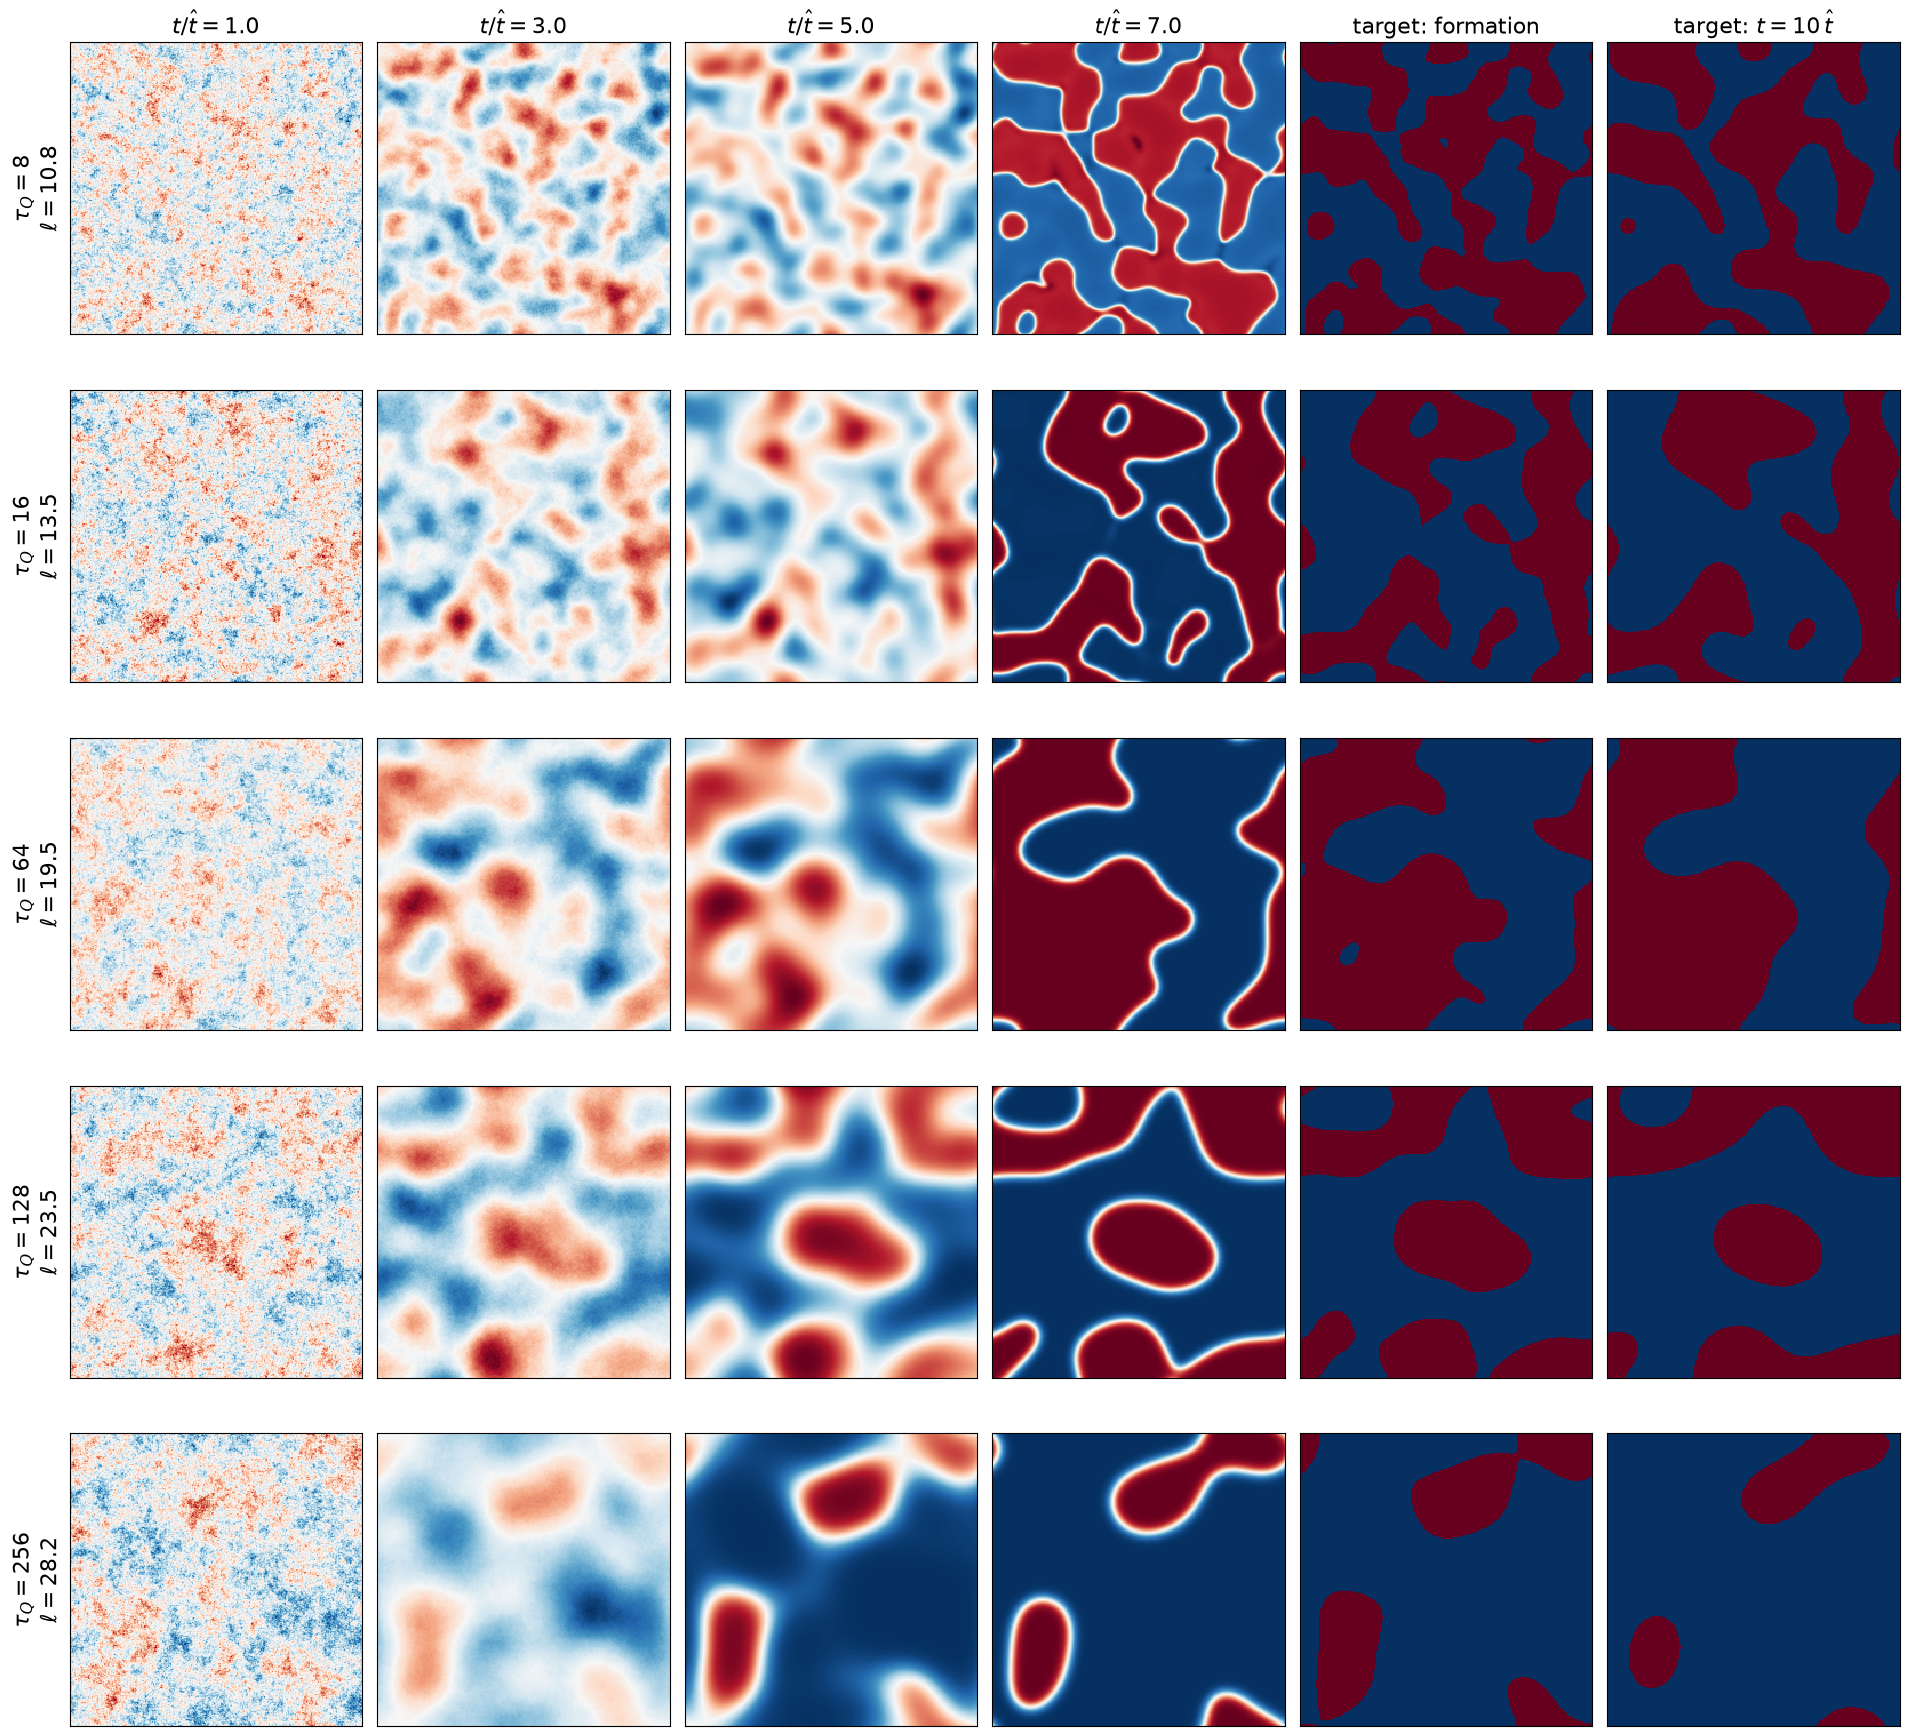

In [3]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]   # missing data is skipped
CHUNK    = 0
SAMPLE   = 0
SHOW_HAT = [1,3,5,7]            # snapshot times to show, in units of t_hat
DX       = 0.5
FONTSIZE = 16

# keep only taus with data on this machine
paths = {tau: f"../data/2D_v2/tau{tau}/chunk_{CHUNK:03d}.npz" for tau in TAUS}
taus  = [tau for tau in TAUS if os.path.exists(paths[tau])]
print("showing tau =", taus, "  skipped:", [tau for tau in TAUS if tau not in taus])

n_cols = len(SHOW_HAT) + 2            # snapshots + formation target + end target
fig, axes = plt.subplots(len(taus), n_cols, figsize=(3.2 * n_cols, 3.6 * len(taus)), squeeze=False)

for row, tau in enumerate(taus):
    d = np.load(paths[tau])
    t_hat, xi_hat, N = float(d["t_hat"]), float(d["xi_hat"]), int(d["N"])

    # sanity checks: formation time and KZ domain size in units of t_hat, xi_hat
    tf  = d["t_form"] / t_hat
    ell = (N * DX)**2 / an.wall_length(d["y_form"], dx=DX)
    print(f"tau={tau:4d}  t_form/t_hat = {np.nanmean(tf):.2f} ± {np.nanstd(tf):.2f}   "
          f"ell_form/xi_hat = {ell.mean() / xi_hat:.2f}   (n={len(tf)})")

    # snapshots (per-panel scale: amplitude grows by orders of magnitude)
    for col, s in enumerate(SHOW_HAT):
        i = int(np.argmin(np.abs(d["snap_hat"] - s)))
        f = d["snaps"][SAMPLE, i].astype(np.float32)
        v = np.abs(f).max()
        axes[row, col].imshow(f, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
        if row == 0:
            axes[row, col].set_title(rf"$t/\hat t = {d['snap_hat'][i]:.1f}$", fontsize=FONTSIZE)

    # targets
    axes[row, -2].imshow(d["y_form"][SAMPLE], cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
    axes[row, -1].imshow(d["y_end"][SAMPLE],  cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
    if row == 0:
        axes[row, -2].set_title("target: formation", fontsize=FONTSIZE)
        axes[row, -1].set_title(rf"target: $t = {float(d['t_max_hat']):.0f}\,\hat t$", fontsize=FONTSIZE)

    axes[row, 0].set_ylabel(rf"$\tau_Q = {tau}$" + "\n" + rf"$\ell = {ell.mean():.1f}$", fontsize=FONTSIZE)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("../figures/2d/representative_chunks.png", dpi=150)
plt.show()

We see that early (in units of $\hat t$) that we can see the final formation being set. As time continues toe volve the system, this domain becomes more well defined, with ambigious regions shrinking.  

Notice for the largest quench times that the regions seem well defined even as early as $\frac{t}{\hat t}=2$

You'll notice next to $\tau$ we include a measure of the size of these domains, $l$. 

We define $l$ as 
$$l = \frac{A}{L_\text{domains}}$$

It is the ratio of the full area of the system to the length of the perimiters of the areas in the figures. 

To show that this is the proper notion of length, we demonstrate below that it scales as a power law with the quench time.

tau=   8  t_f/t_hat=6.00  ell= 10.90  ell/xi_hat=5.45
tau=  10  t_f/t_hat=5.93  ell= 12.02  ell/xi_hat=5.68
tau=  13  t_f/t_hat=5.74  ell= 13.20  ell/xi_hat=5.84
tau=  16  t_f/t_hat=5.66  ell= 13.99  ell/xi_hat=5.88
tau=  20  t_f/t_hat=5.53  ell= 14.34  ell/xi_hat=5.70
tau=  25  t_f/t_hat=5.44  ell= 15.69  ell/xi_hat=5.90
tau=  32  t_f/t_hat=5.38  ell= 16.57  ell/xi_hat=5.86
tau=  40  t_f/t_hat=5.28  ell= 17.46  ell/xi_hat=5.84
tau=  51  t_f/t_hat=5.20  ell= 18.75  ell/xi_hat=5.90
tau=  64  t_f/t_hat=5.13  ell= 20.56  ell/xi_hat=6.11
tau=  81  t_f/t_hat=5.05  ell= 21.01  ell/xi_hat=5.89
tau= 102  t_f/t_hat=4.99  ell= 23.40  ell/xi_hat=6.19
tau= 128  t_f/t_hat=4.91  ell= 28.85  ell/xi_hat=7.21
tau= 161  t_f/t_hat=4.88  ell= 24.42  ell/xi_hat=5.77
tau= 203  t_f/t_hat=4.85  ell= 26.81  ell/xi_hat=5.97
tau= 256  t_f/t_hat=4.80  ell= 27.53  ell/xi_hat=5.79


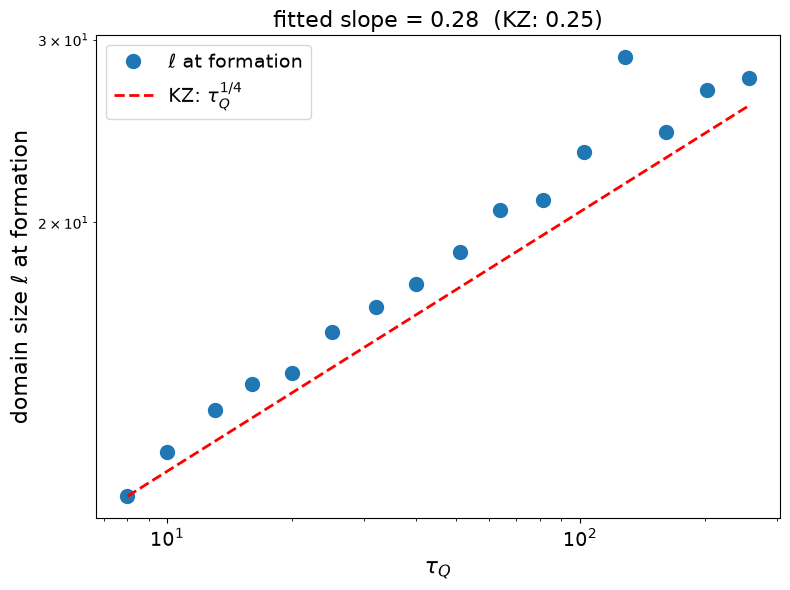

In [4]:
# ---- inputs ----
RESULTS  = "../results/kz_scaling.json"
FONTSIZE = 16

r      = json.load(open(RESULTS))["results"]
taus   = np.array([x["tau"] for x in r])
ell    = np.array([x["ell"] for x in r])
xi_hat = np.array([x["xi_hat"] for x in r])
t_rat  = np.array([x["t_f"] / x["t_hat"] for x in r])

for tau, l, xh, tr in zip(taus, ell, xi_hat, t_rat):
    print(f"tau={tau:4d}  t_f/t_hat={tr:4.2f}  ell={l:6.2f}  ell/xi_hat={l / xh:4.2f}")

slope = np.polyfit(np.log(taus), np.log(ell), 1)[0]

plt.figure(figsize=(8, 6))
plt.plot(taus, ell, "o", ms=10, label=r"$\ell$ at formation")
plt.plot(taus, ell[0] * (taus / taus[0])**0.25, "r--", lw=2, label=r"KZ: $\tau_Q^{1/4}$")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\tau_Q$", fontsize=FONTSIZE)
plt.ylabel(r"domain size $\ell$ at formation", fontsize=FONTSIZE)
plt.title(rf"fitted slope = {slope:.2f}  (KZ: 0.25)", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("../figures/2d/kz_scaling.png", dpi=150)
plt.show()

The above plot tell us that the length $l$ grows close to the kibble-zurek prediction for this model of $\tau^{1/4}$. The relation is not exact. Deviations from this prediction can be attributed to a low sample size of domain distributions (each data point above represents only 10 runs), finite system size, and dynamical coarsening. 

# The machine learning question

How much of the final domain can be inferred from a snapshot of $t/\hat t$?

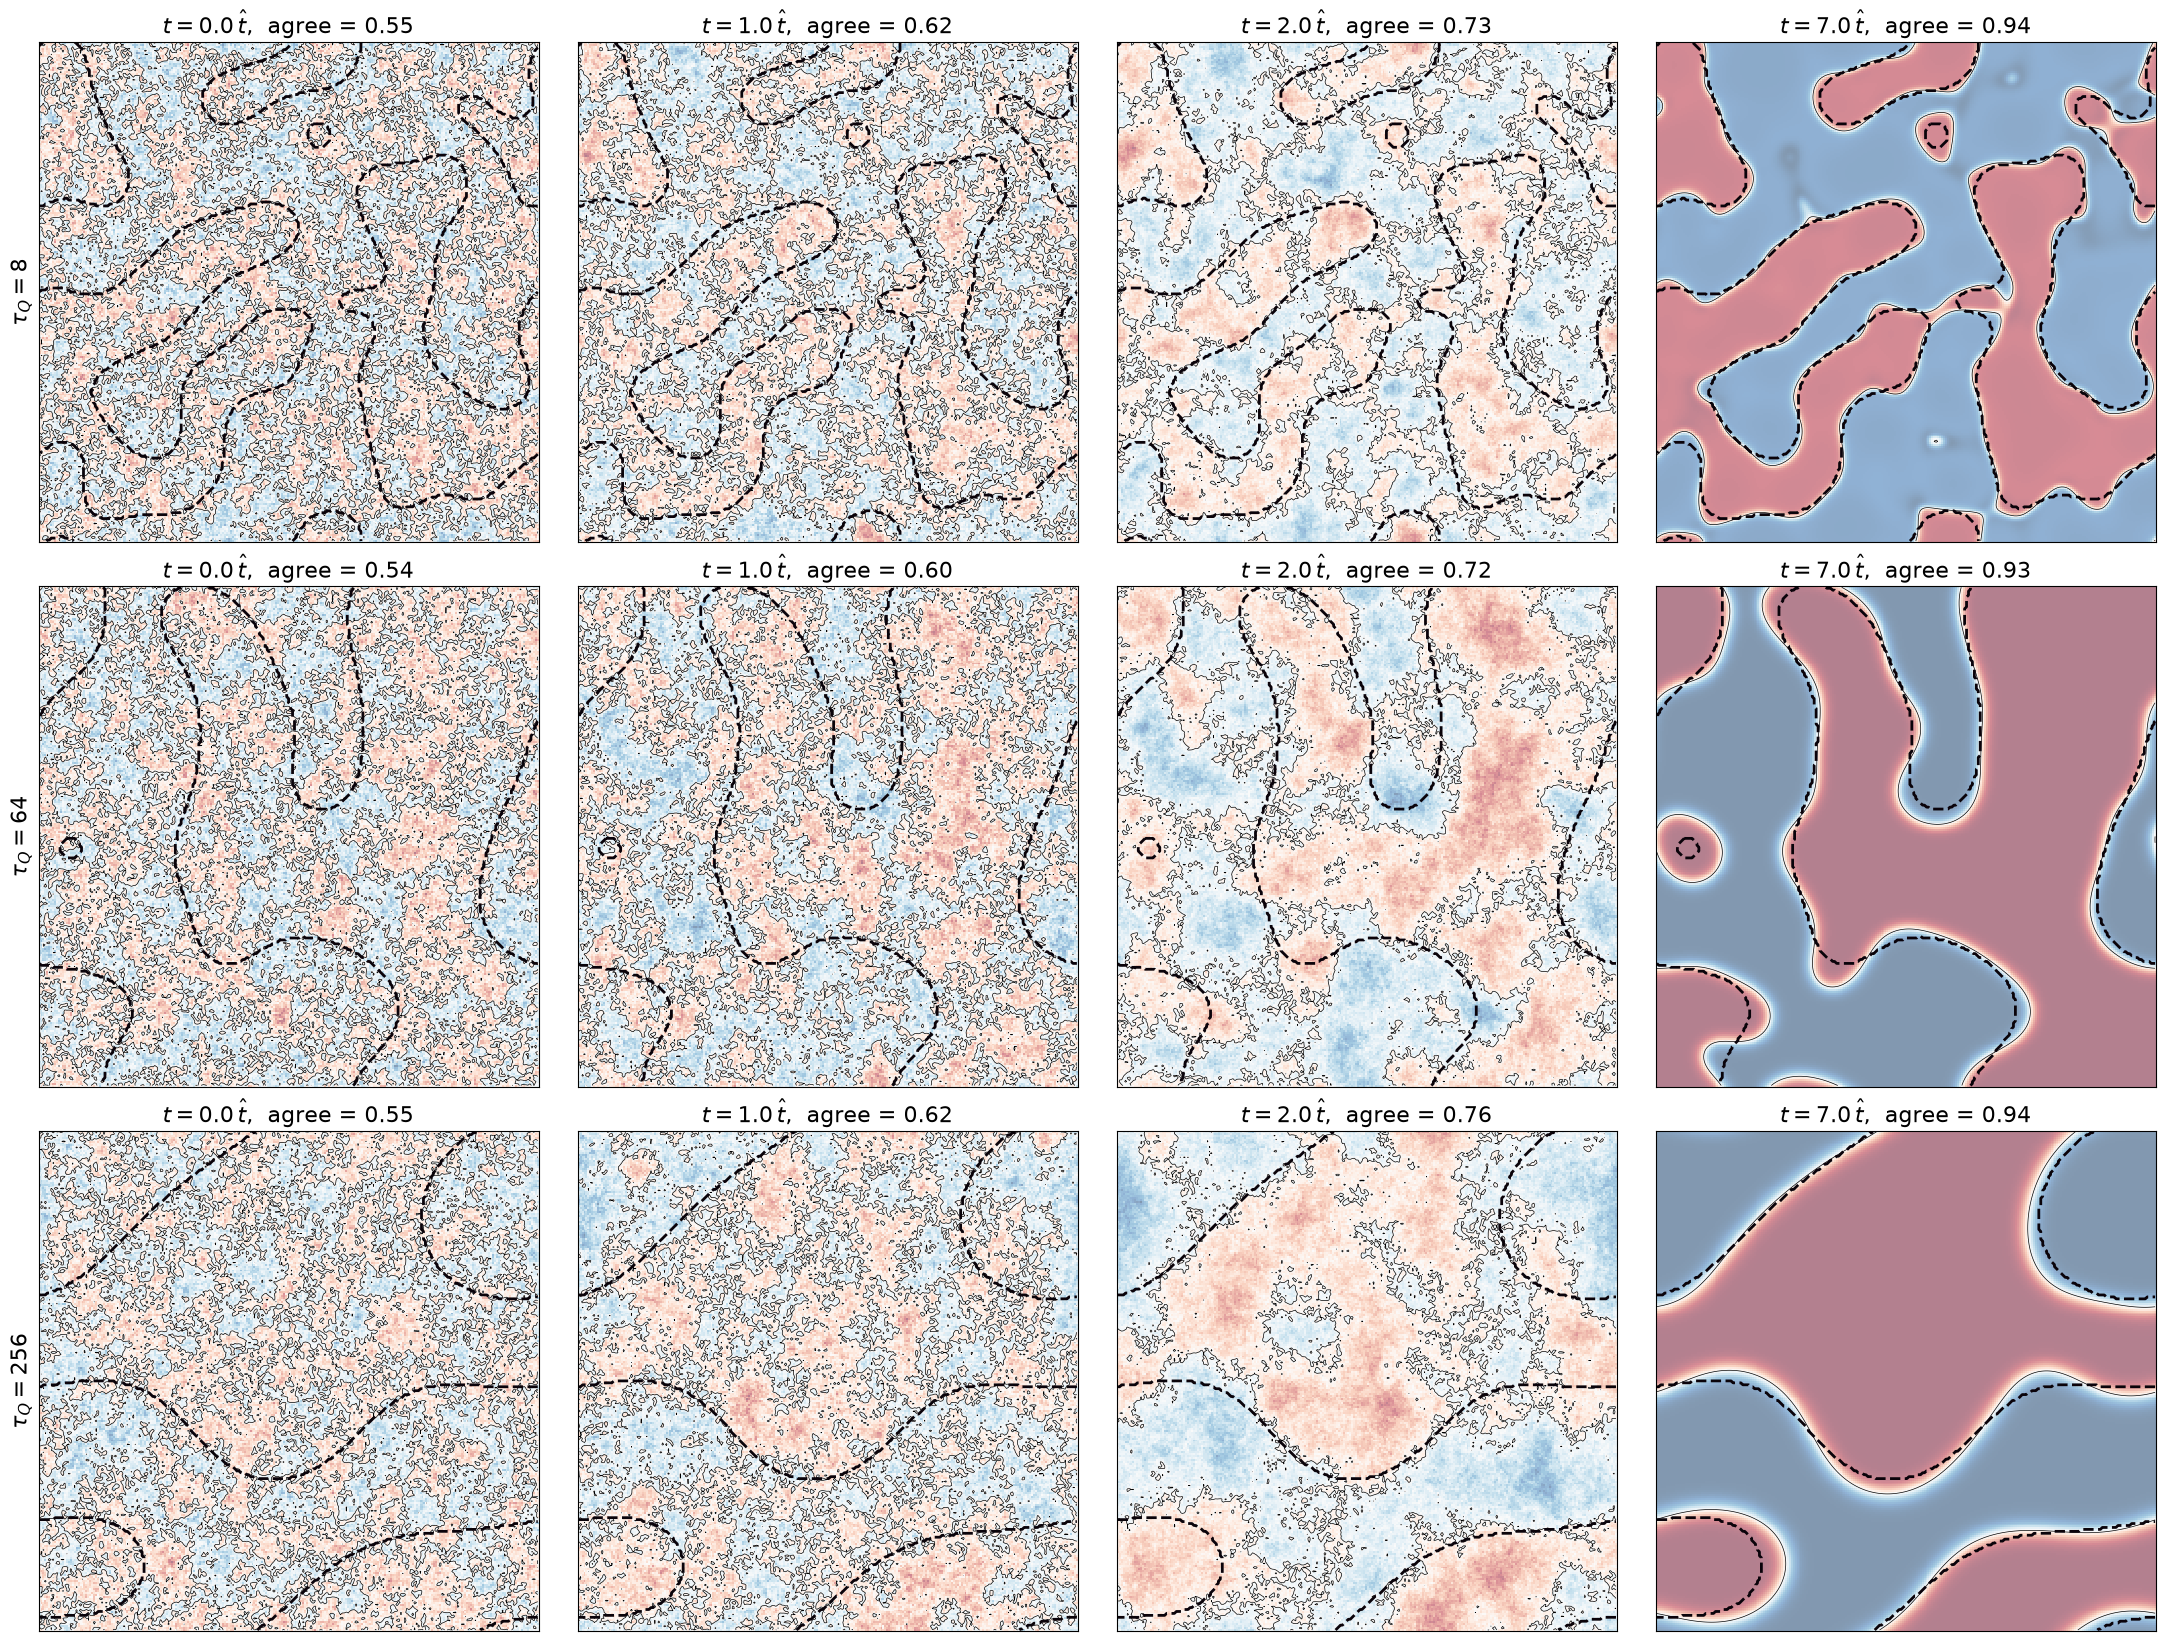

In [7]:
# ---- inputs ----
TAUS      = [8, 64, 256]   # missing data is skipped
CHUNK     = 0
SAMPLE    = 3
TIMES_HAT = [.25,1.0,2, 7]                  # two snapshot times to compare, units of t_hat
FONTSIZE  = 16

# keep only taus with data on this machine
paths = {tau: f"../data/2D_v2/tau{tau}/chunk_{CHUNK:03d}.npz" for tau in TAUS}
taus  = [tau for tau in TAUS if os.path.exists(paths[tau])]

fig, axes = plt.subplots(len(taus), len(TIMES_HAT),
                         figsize=(5.5 * len(TIMES_HAT), 5.5 * len(taus)), squeeze=False)

for row, tau in enumerate(taus):
    d     = np.load(paths[tau])
    y_end = d["y_end"][SAMPLE]

    for col, s in enumerate(TIMES_HAT):
        i = int(np.argmin(np.abs(d["snap_hat"] - s)))
        f = d["snaps"][SAMPLE, i].astype(np.float32)
        agree = ((f > 0) == y_end).mean()           # persistence: sign at t already matches end

        ax = axes[row, col]
        v  = np.abs(f).max()
        ax.imshow(f, cmap="RdBu_r", vmin=-v, vmax=v, alpha=0.5, interpolation="nearest")
        ax.contour(f,                  levels=[0],   colors="k",       linewidths=.5)   # walls at t
        ax.contour(y_end.astype(float), levels=[0.5], colors="#0a030a", linewidths=2,ls="--")  # end walls
        ax.set_title(rf"$t = {d['snap_hat'][i]:.1f}\,\hat t$,  agree = {agree:.2f}", fontsize=FONTSIZE)
        ax.set_xticks([]); ax.set_yticks([])

    axes[row, 0].set_ylabel(rf"$\tau_Q = {tau}$", fontsize=FONTSIZE)

#fig.suptitle(r"black = walls at $t$,  pink = walls at end", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig("../figures/2d/walls_vs_end.png", dpi=150)
plt.show()

It might be obvious that a model might be able to learn the end formations given situations like $t=7\hat t$, but it's less so at $t=\hat t$. Furthermore, what of times before this freezeout time? While this problem was tackled in 1d before, it has not been treated in two dimensions.

Kibble zurek physics is interesting because it probes a type of universality. Notice that depsite the fact the fact that each quench is run at different $\tau$, for specificed $t=n \hat t$ the percentage of their spins that agree with the final field value is approximately the same. We can investigate this property further:

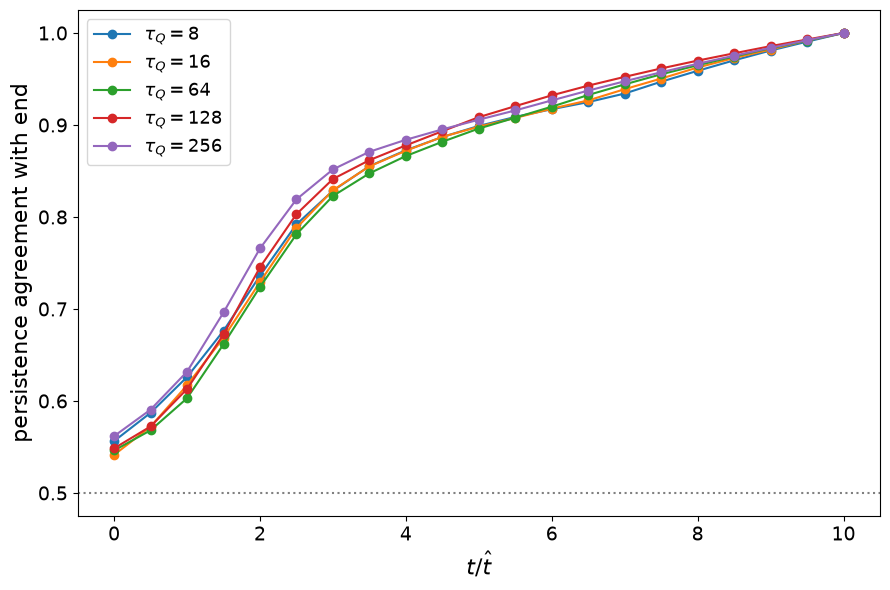

In [9]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]   # missing data is skipped
CHUNK    = 0
FONTSIZE = 16

plt.figure(figsize=(9, 6))
for tau in TAUS:
    path = f"../data/2D_v2/tau{tau}/chunk_{CHUNK:03d}.npz"
    if not os.path.exists(path):
        continue
    d     = np.load(path)
    y_end = d["y_end"]                                        # (n, N, N)
    agree = [((d["snaps"][:, i] > 0) == y_end).mean()         # average over samples and sites
             for i in range(len(d["snap_hat"]))]
    plt.plot(d["snap_hat"], agree, "o-", ms=6, lw=1.5, label=rf"$\tau_Q = {tau}$")

plt.axhline(0.5, color="grey", ls=":", lw=1.5)
plt.xlabel(r"$t/\hat t$", fontsize=FONTSIZE)
plt.ylabel("persistence agreement with end", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 3)
plt.tight_layout()
plt.savefig("../figures/2d/persistence_collapse.png", dpi=150)
plt.show()

From this, we can see the univeral "freezeout" physics on pure display! After a certain hold time, each run dramatically increases its accuracy to approximately the same values!